#1. Для всех изображений примените фильтр, фильтр Гаусса и медианный фильтр с размером маски (ядра) 3x3, 5x5, 7x7, 9x9.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 12]
plt.rcParams['figure.dpi'] = 100

def apply_filters(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Ошибка: не удалось загрузить {image_path}")
        return None

    results = {'original': img, 'name': image_path}

    #Размеры ядер
    kernel_sizes = [3, 5, 7, 9]

    #Гауссов фильтр
    for k in kernel_sizes:
        results[f'gauss_{k}x{k}'] = cv2.GaussianBlur(img, (k, k), 0)

    #Медианный фильтр
    for k in kernel_sizes:
        results[f'median_{k}x{k}'] = cv2.medianBlur(img, k)

    #Усредняющий фильтр
    for k in kernel_sizes:
        kernel = np.ones((k, k), np.float32) / (k * k)
        results[f'average_{k}x{k}'] = cv2.filter2D(img, -1, kernel)

    return results

image_paths = [
    'Bri.jpg',
    'Building.jpg',
    'Camera.jpg',
    'Light.jpg',
    'Noisy Lena.jpg',
    'Statue.jpg',
    'Truck.jpg'
]

#Обрабатываем все изображения
results = {}
for path in image_paths:
    result = apply_filters(path)
    if result is not None:
        results[path] = result

#Визуализация результатов
if results:
    for img_name, img_results in results.items():
        # Первый график: сравнение фильтров
        fig, axes = plt.subplots(3, 5, figsize=(20, 15))
        fig.suptitle(f'Сравнение фильтров: {img_name}', fontsize=16)

        #Первая строка - оригинал и Гаусс
        axes[0, 0].imshow(img_results['original'], cmap='gray')
        axes[0, 0].set_title('Оригинал')
        axes[0, 0].axis('off')

        #Гауссов фильтр
        gauss_titles = ['Гаусс 3x3', 'Гаусс 5x5', 'Гаусс 7x7', 'Гаусс 9x9']
        for i, k in enumerate([3, 5, 7, 9]):
            axes[0, i+1].imshow(img_results[f'gauss_{k}x{k}'], cmap='gray')
            axes[0, i+1].set_title(gauss_titles[i])
            axes[0, i+1].axis('off')

        #Вторая строка - медианный фильтр
        axes[1, 0].axis('off')
        median_titles = ['Медианный 3x3', 'Медианный 5x5', 'Медианный 7x7', 'Медианный 9x9']
        for i, k in enumerate([3, 5, 7, 9]):
            axes[1, i+1].imshow(img_results[f'median_{k}x{k}'], cmap='gray')
            axes[1, i+1].set_title(median_titles[i])
            axes[1, i+1].axis('off')

        #Третья строка - усредняющий фильтр
        axes[2, 0].axis('off')
        avg_titles = ['Усредняющий 3x3', 'Усредняющий 5x5', 'Усредняющий 7x7', 'Усредняющий 9x9']
        for i, k in enumerate([3, 5, 7, 9]):
            axes[2, i+1].imshow(img_results[f'average_{k}x{k}'], cmap='gray')
            axes[2, i+1].set_title(avg_titles[i])
            axes[2, i+1].axis('off')

        plt.tight_layout()
        plt.show()

        #Второй график: гистограммы
        fig_h, axes_h = plt.subplots(3, 5, figsize=(20, 12))
        fig_h.suptitle(f'Гистограммы: {img_name}', fontsize=16)

        axes_h[0, 0].hist(img_results['original'].ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
        axes_h[0, 0].set_title('Оригинал')
        axes_h[1, 0].axis('off')
        axes_h[2, 0].axis('off')

        #Гистограммы Гаусса
        for i, k in enumerate([3, 5, 7, 9]):
            axes_h[0, i+1].hist(img_results[f'gauss_{k}x{k}'].ravel(), bins=256, range=(0, 256), color='red', alpha=0.7)
            axes_h[0, i+1].set_title(f'Гаусс {k}x{k}')

        #Гистограммы медианного
        for i, k in enumerate([3, 5, 7, 9]):
            axes_h[1, i+1].hist(img_results[f'median_{k}x{k}'].ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
            axes_h[1, i+1].set_title(f'Медианный {k}x{k}')

        #Гистограммы усредняющего
        for i, k in enumerate([3, 5, 7, 9]):
            axes_h[2, i+1].hist(img_results[f'average_{k}x{k}'].ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
            axes_h[2, i+1].set_title(f'Усредняющий {k}x{k}')

        plt.tight_layout()
        plt.show()

        fig_comp, axes_comp = plt.subplots(4, 4, figsize=(16, 16))
        fig_comp.suptitle(f'Сравнение фильтров по размерам: {img_name}', fontsize=16)

        for col, k in enumerate([3, 5, 7, 9]):
            axes_comp[0, col].imshow(img_results['original'], cmap='gray')
            axes_comp[0, col].set_title(f'Оригинал (для {k}x{k})')
            axes_comp[0, col].axis('off')

            axes_comp[1, col].imshow(img_results[f'gauss_{k}x{k}'], cmap='gray')
            axes_comp[1, col].set_title(f'Гаусс {k}x{k}')
            axes_comp[1, col].axis('off')

            axes_comp[2, col].imshow(img_results[f'median_{k}x{k}'], cmap='gray')
            axes_comp[2, col].set_title(f'Медианный {k}x{k}')
            axes_comp[2, col].axis('off')

            axes_comp[3, col].imshow(img_results[f'average_{k}x{k}'], cmap='gray')
            axes_comp[3, col].set_title(f'Усредняющий {k}x{k}')
            axes_comp[3, col].axis('off')

        plt.tight_layout()
        plt.show()


#2. С использованием filter2D реализуйте фильтрыПревитта, СобеляиРобертса. Что можно сказать про результаты фильтрации? Чтоможносказатьпро полученные изображения на основе анализа гистограмм?

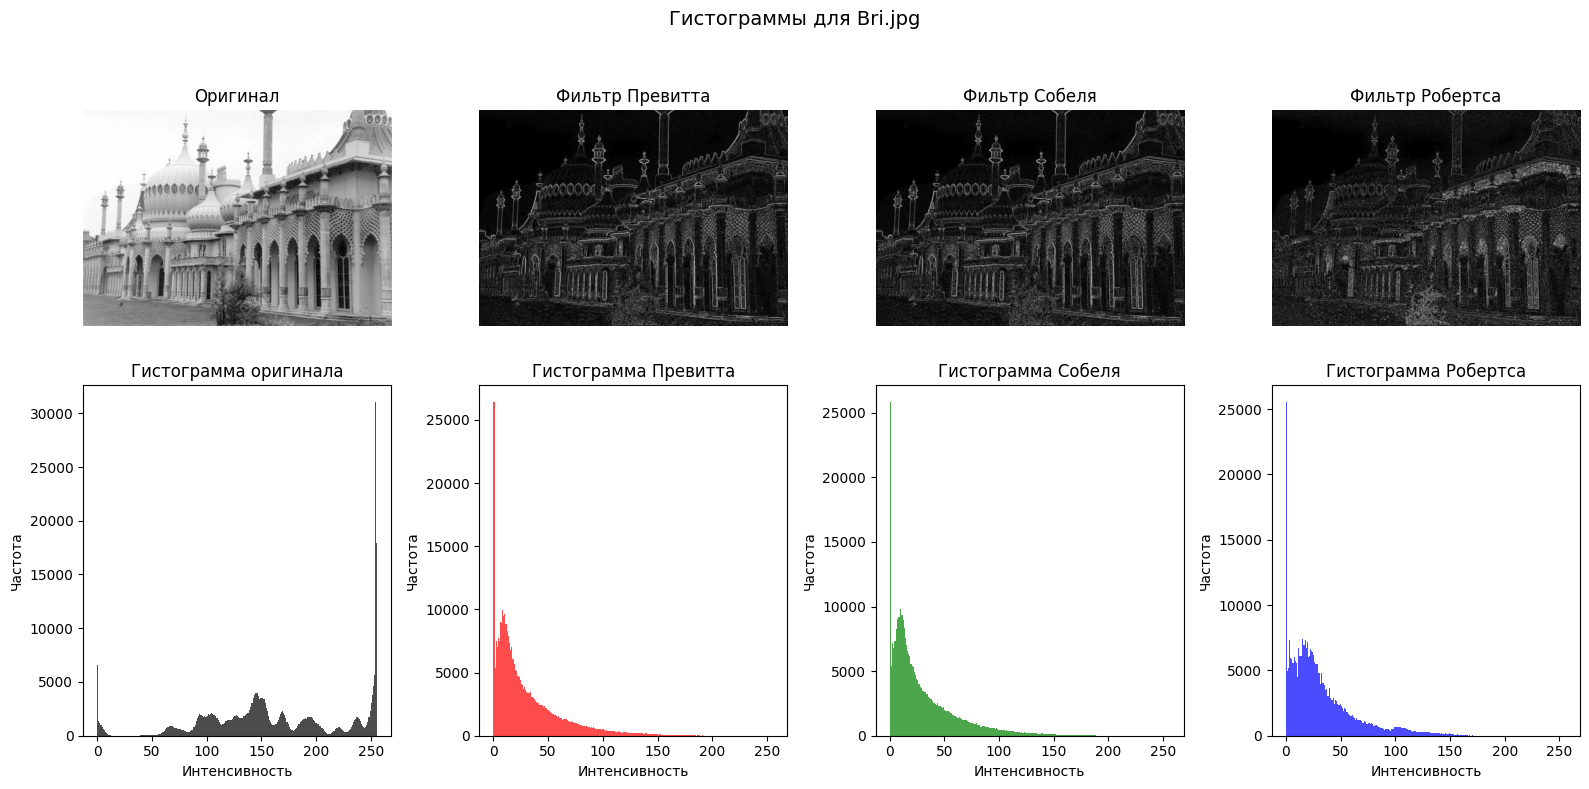

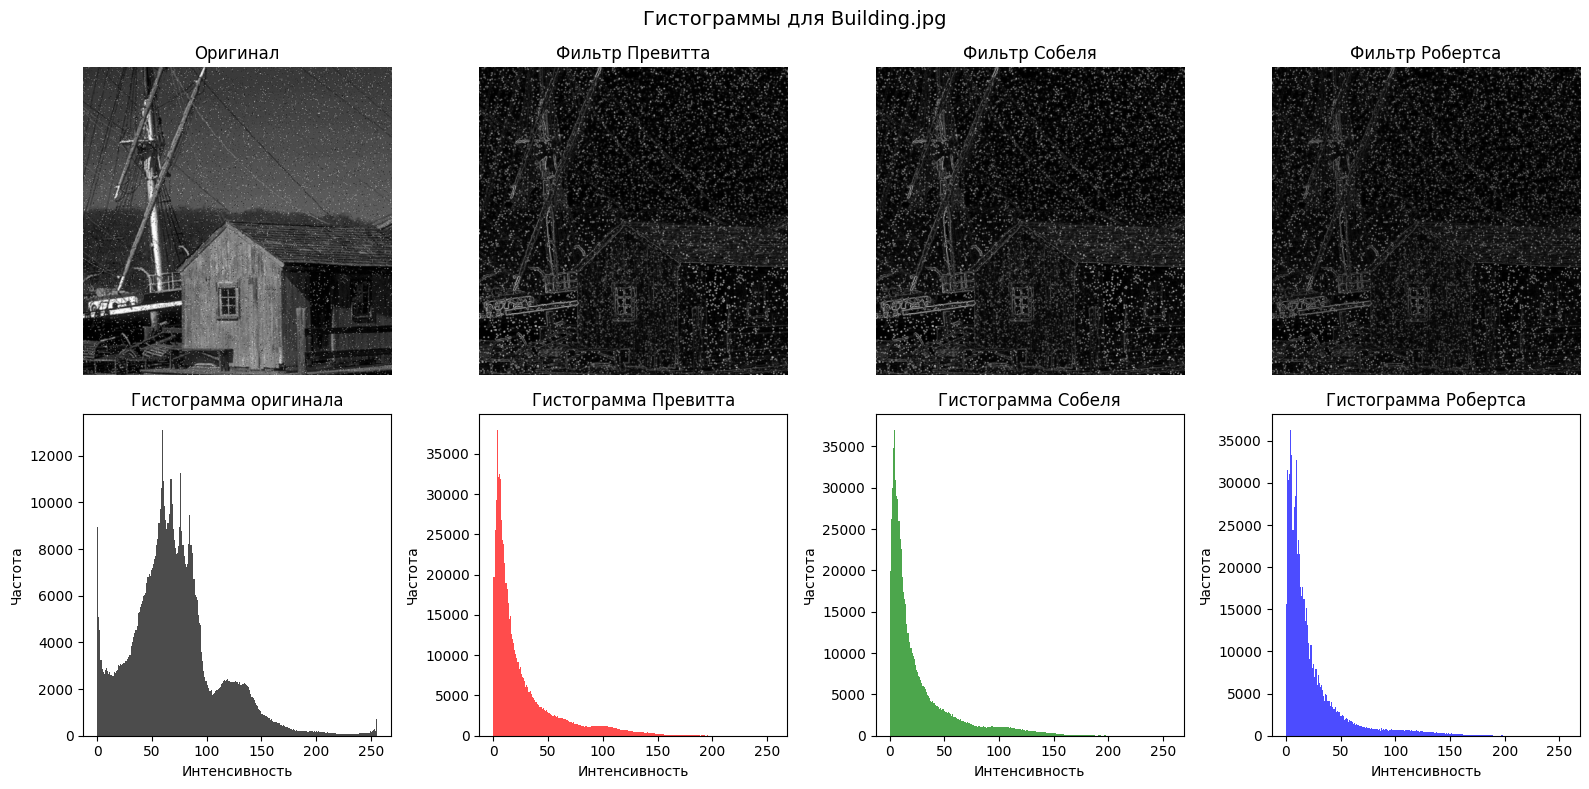

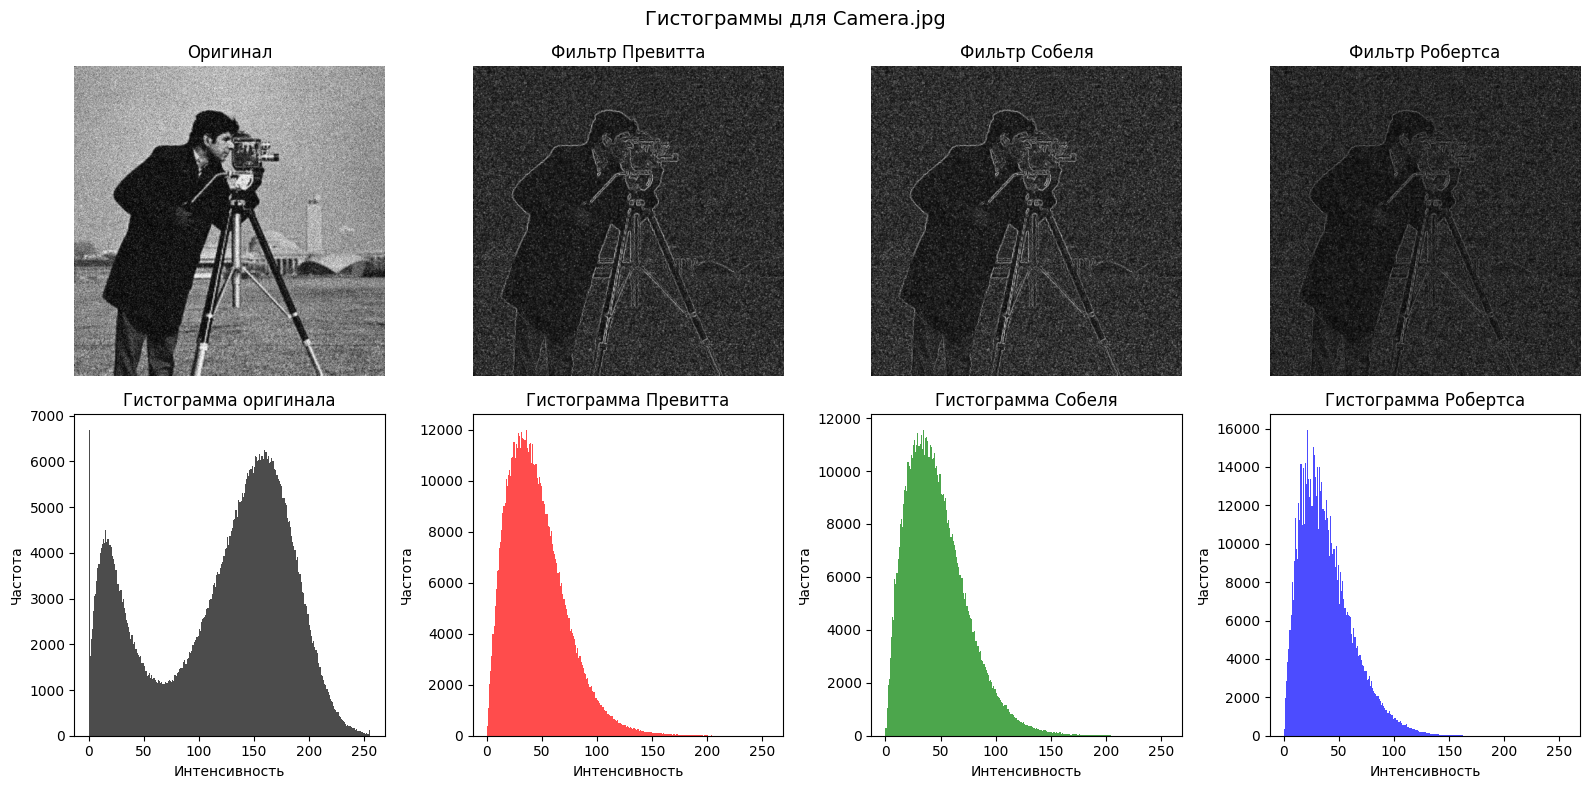

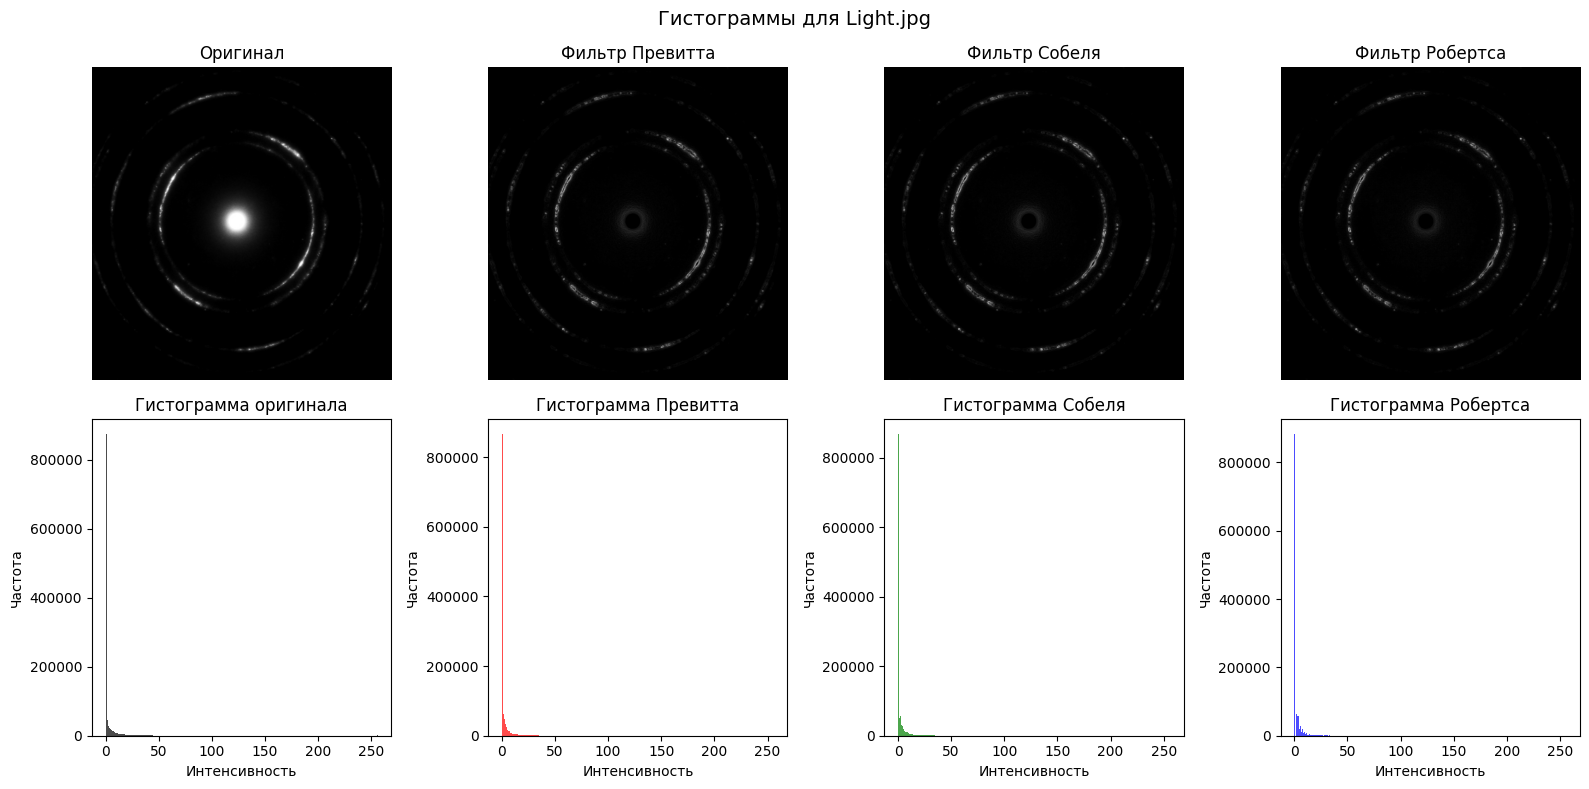

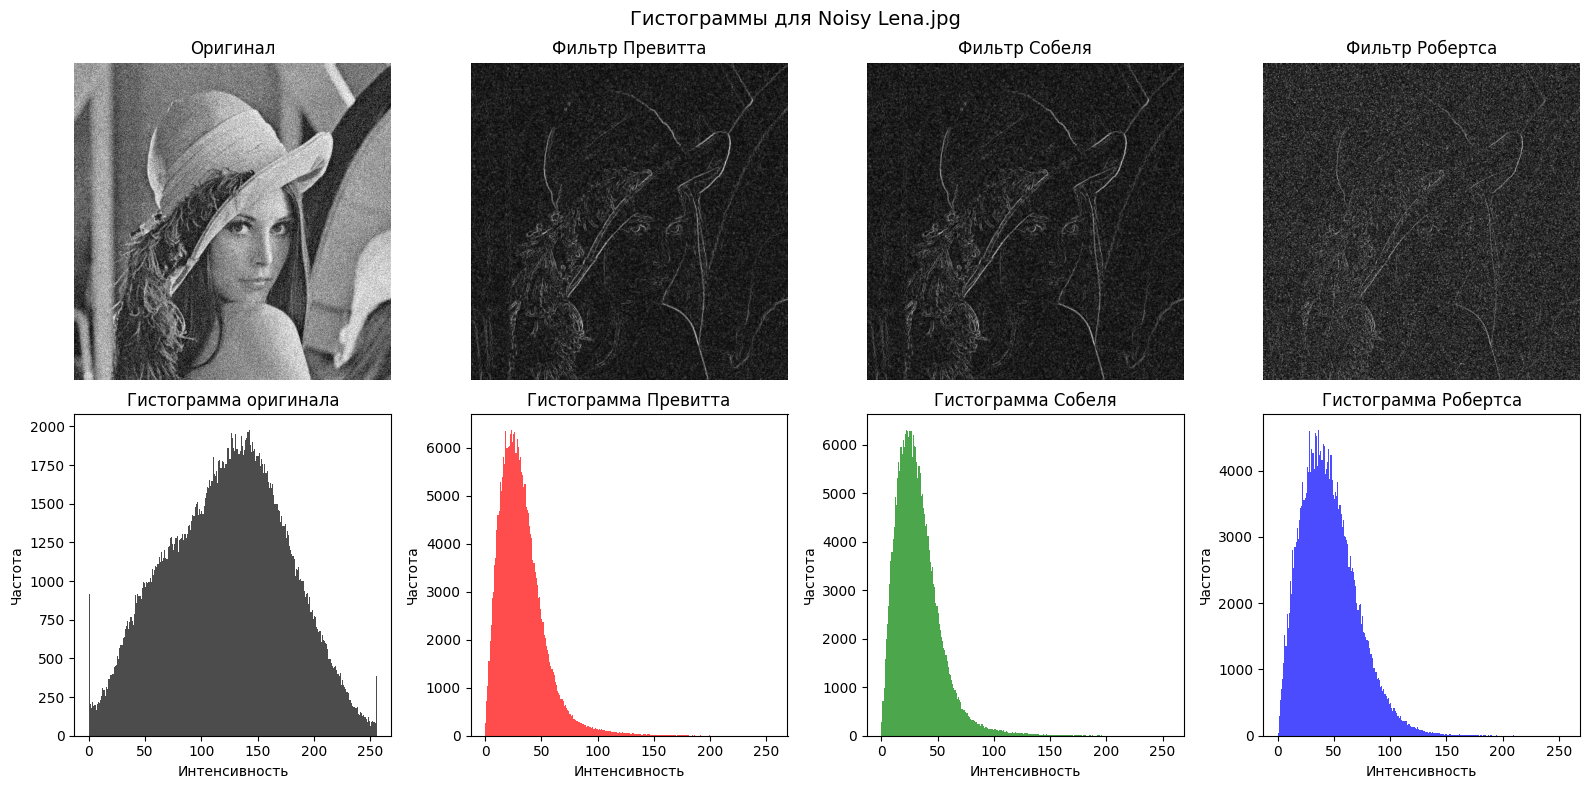

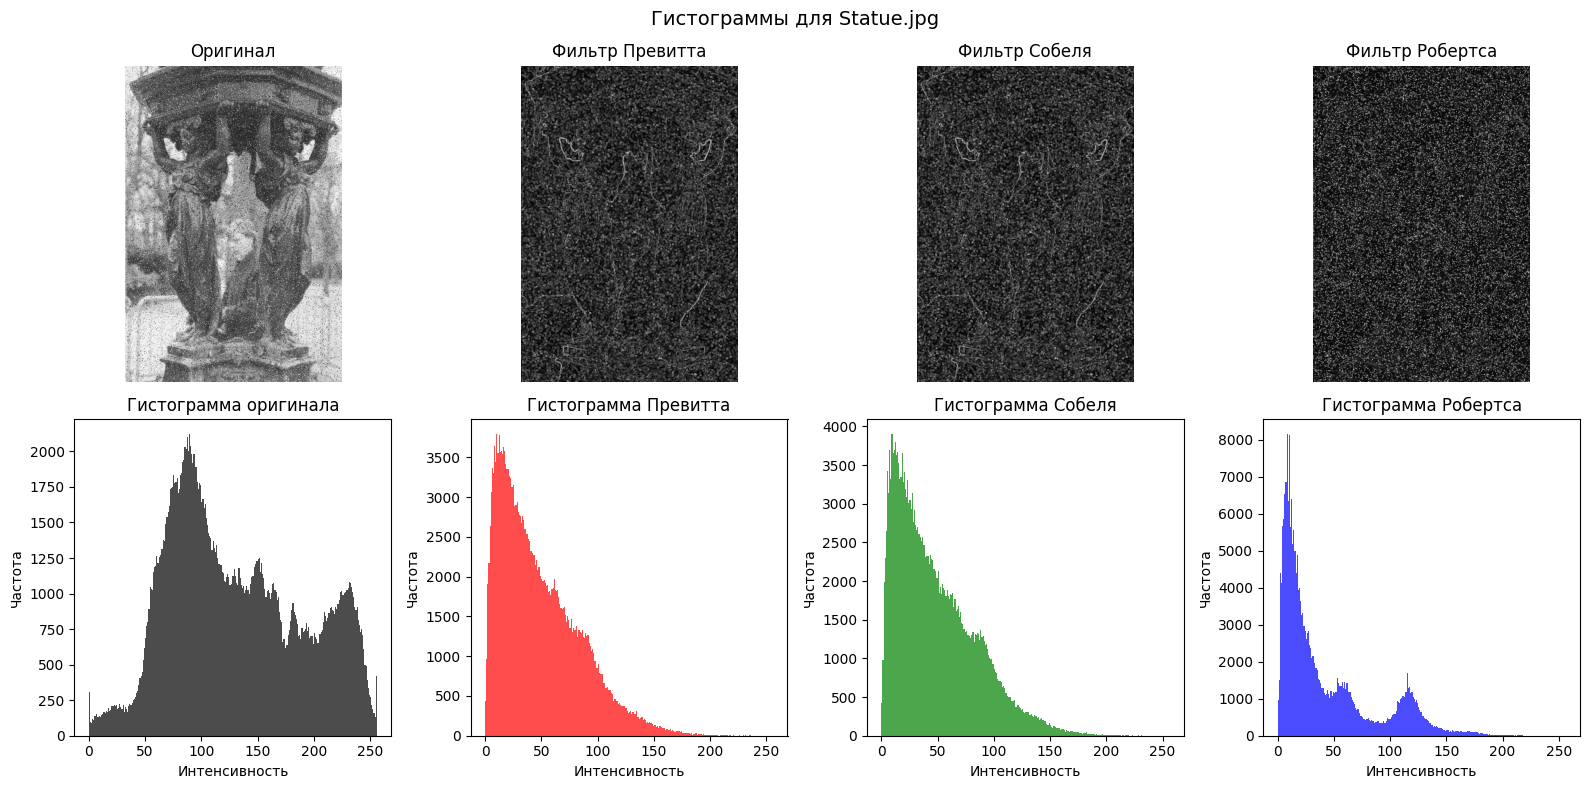

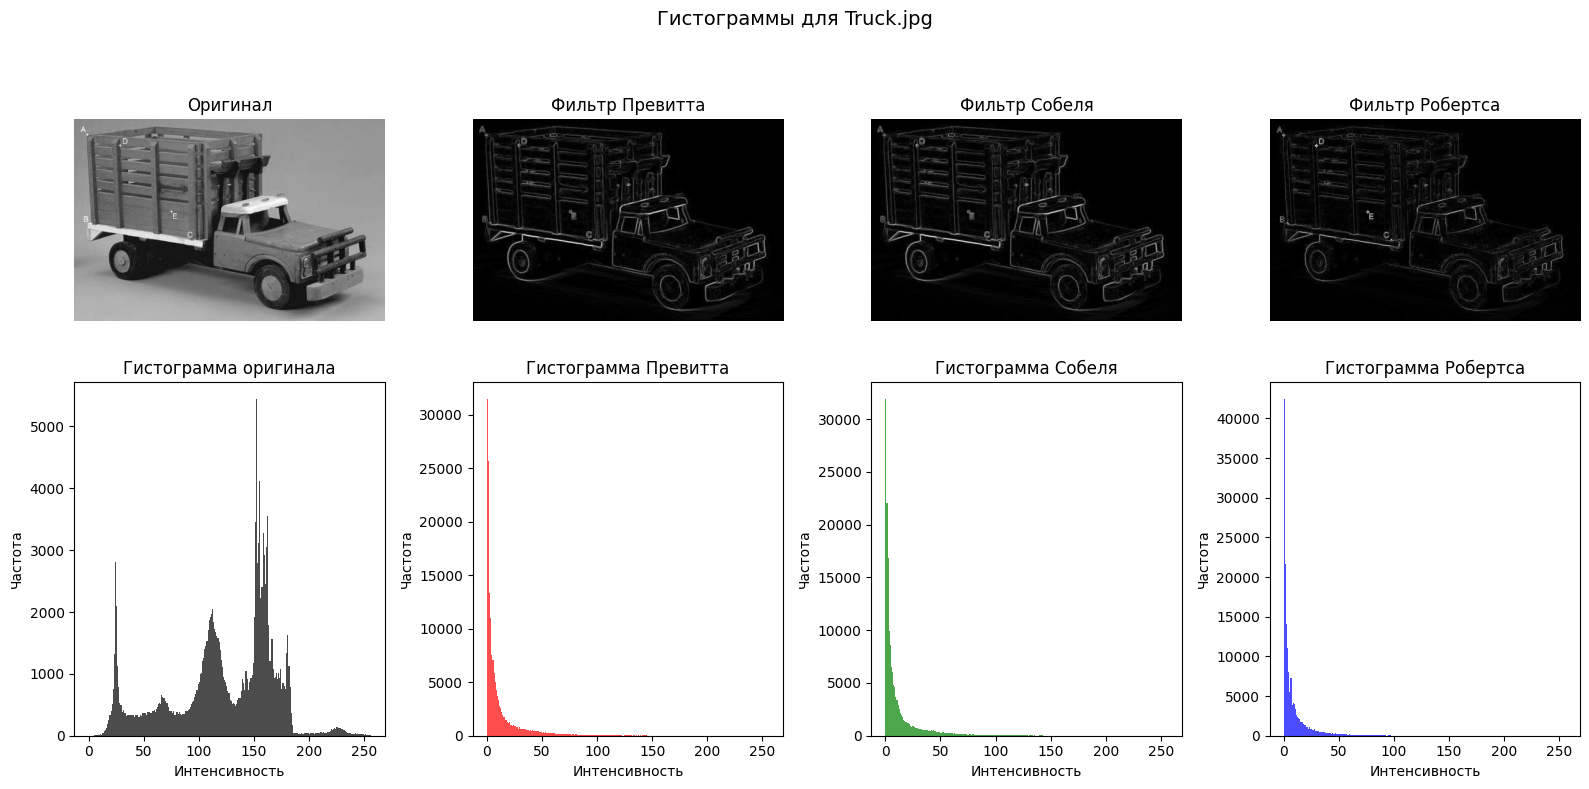

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['figure.dpi'] = 100

def apply_filters(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Не удалось загрузить изображение: {image_path}")
        return None

    #Ядра фильтров
    #Превитт
    prewitt_x = np.array([[-1, 0, 1],
                          [-1, 0, 1],
                          [-1, 0, 1]], dtype=np.float32)
    prewitt_y = np.array([[-1, -1, -1],
                          [0, 0, 0],
                          [1, 1, 1]], dtype=np.float32)

    #Собель
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float32)

    #Робертс
    roberts_x = np.array([[1, 0],
                          [0, -1]], dtype=np.float32)
    roberts_y = np.array([[0, 1],
                          [-1, 0]], dtype=np.float32)

    results = {'original': img, 'name': image_path}

    #Превитт
    prewitt_x_result = cv2.filter2D(img, cv2.CV_32F, prewitt_x)
    prewitt_y_result = cv2.filter2D(img, cv2.CV_32F, prewitt_y)
    prewitt_magnitude = np.sqrt(prewitt_x_result**2 + prewitt_y_result**2)
    results['prewitt'] = cv2.normalize(prewitt_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    #Собель
    sobel_x_result = cv2.filter2D(img, cv2.CV_32F, sobel_x)
    sobel_y_result = cv2.filter2D(img, cv2.CV_32F, sobel_y)
    sobel_magnitude = np.sqrt(sobel_x_result**2 + sobel_y_result**2)
    results['sobel'] = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    #Робертс
    roberts_x_result = cv2.filter2D(img, cv2.CV_32F, roberts_x)
    roberts_y_result = cv2.filter2D(img, cv2.CV_32F, roberts_y)
    roberts_magnitude = np.sqrt(roberts_x_result**2 + roberts_y_result**2)
    results['roberts'] = cv2.normalize(roberts_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return results

image_paths = [
    'Bri.jpg',
    'Building.jpg',
    'Camera.jpg',
    'Light.jpg',
    'Noisy Lena.jpg',
    'Statue.jpg',
    'Truck.jpg'
]

results = {}
for path in image_paths:
    result = apply_filters(path)
    if result is not None:
        results[path] = result

if results:
    for img_name, img_results in results.items():
        fig_h, axes_h = plt.subplots(2, 4, figsize=(16, 8))
        fig_h.suptitle(f'Гистограммы для {img_name}', fontsize=14)

        axes_h[0, 0].imshow(img_results['original'], cmap='gray')
        axes_h[0, 0].set_title('Оригинал')
        axes_h[0, 0].axis('off')

        axes_h[1, 0].hist(img_results['original'].ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
        axes_h[1, 0].set_title('Гистограмма оригинала')
        axes_h[1, 0].set_xlabel('Интенсивность')
        axes_h[1, 0].set_ylabel('Частота')

        #Превитт
        axes_h[0, 1].imshow(img_results['prewitt'], cmap='gray')
        axes_h[0, 1].set_title('Фильтр Превитта')
        axes_h[0, 1].axis('off')

        axes_h[1, 1].hist(img_results['prewitt'].ravel(), bins=256, range=(0, 256), color='red', alpha=0.7)
        axes_h[1, 1].set_title('Гистограмма Превитта')
        axes_h[1, 1].set_xlabel('Интенсивность')
        axes_h[1, 1].set_ylabel('Частота')

        #Собель
        axes_h[0, 2].imshow(img_results['sobel'], cmap='gray')
        axes_h[0, 2].set_title('Фильтр Собеля')
        axes_h[0, 2].axis('off')

        axes_h[1, 2].hist(img_results['sobel'].ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
        axes_h[1, 2].set_title('Гистограмма Собеля')
        axes_h[1, 2].set_xlabel('Интенсивность')
        axes_h[1, 2].set_ylabel('Частота')

        #Робертс
        axes_h[0, 3].imshow(img_results['roberts'], cmap='gray')
        axes_h[0, 3].set_title('Фильтр Робертса')
        axes_h[0, 3].axis('off')

        axes_h[1, 3].hist(img_results['roberts'].ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
        axes_h[1, 3].set_title('Гистограмма Робертса')
        axes_h[1, 3].set_xlabel('Интенсивность')
        axes_h[1, 3].set_ylabel('Частота')

        plt.tight_layout()
        plt.show()